In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [10]:
#reading data

df=pd.read_csv("superstore_data.csv",encoding="latin-1")
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [16]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

df["order_year"]=pd.to_datetime(df["Order Date"]).dt.year
df["order_month"]=pd.to_datetime(df["Order Date"]).dt.month
df["month_name"]=pd.to_datetime(df["Order Date"]).dt.month_name()

In [23]:
total_sales=df["Sales"].sum()
total_profit=df["Profit"].sum()

print(f"{total_sales:.2f}")
print(f"{total_sales:.2f}")

2297200.86
2297200.86


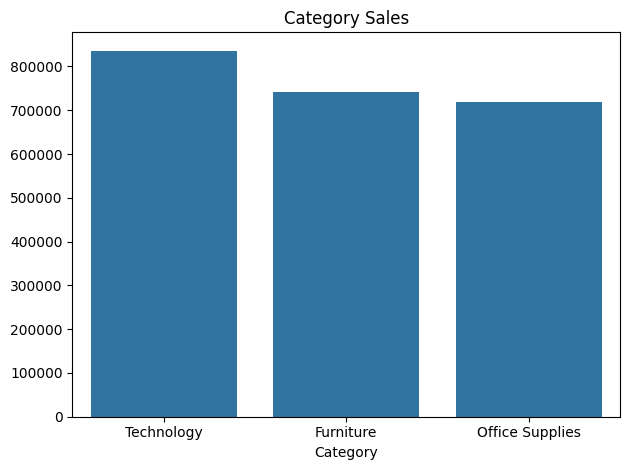

In [27]:
category_sales=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Category Sales")
plt.tight_layout()

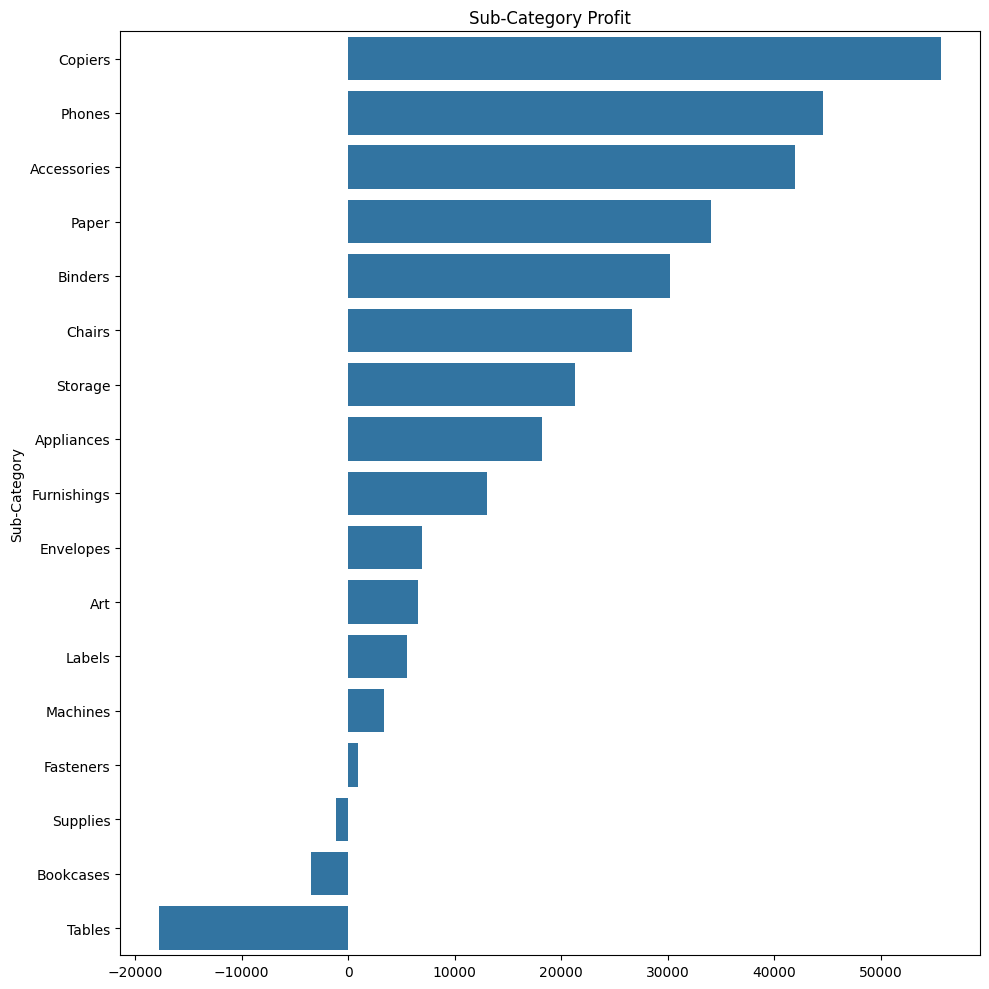

In [31]:
sub_category_profit=df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

fig=plt.subplots(figsize=(10,10))

sns.barplot(
    y=sub_category_profit.index,
    x=sub_category_profit.values
)
plt.title("Sub-Category Profit")
plt.tight_layout()

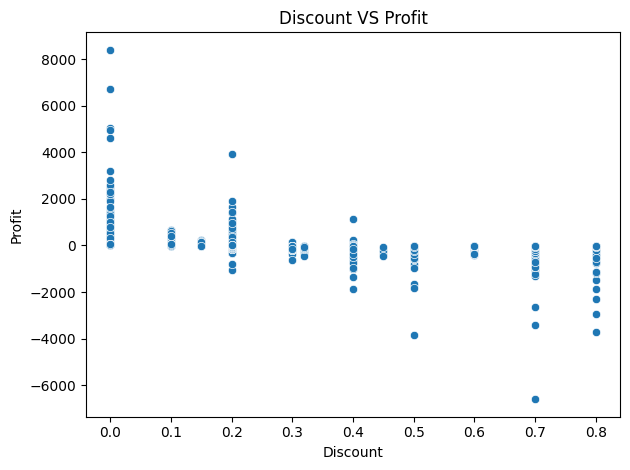

In [34]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)
plt.title("Discount VS Profit")
plt.tight_layout()


<Axes: >

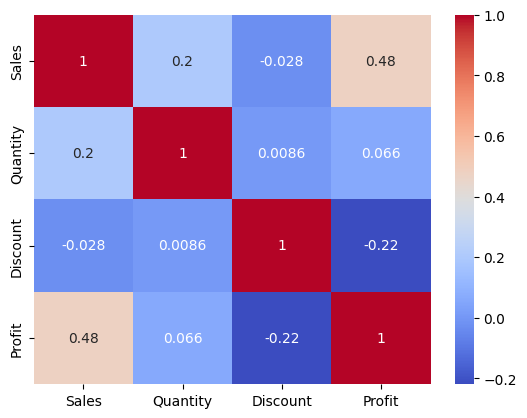

In [38]:
sns.heatmap(
    df[["Sales","Quantity","Discount","Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)

<Axes: xlabel='order_month', ylabel='Sales'>

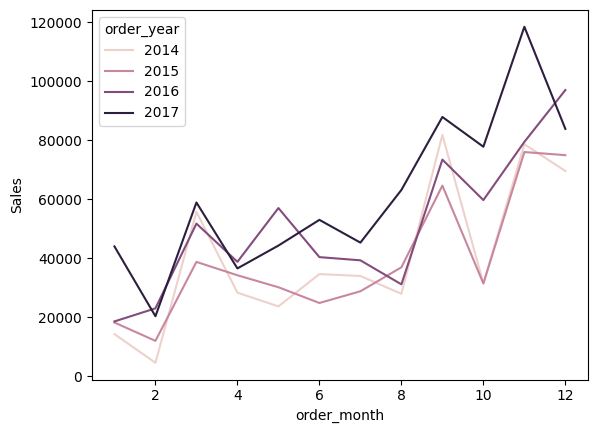

In [40]:
monthly_sales=df.groupby(["order_month","order_year"])["Sales"].sum().reset_index()

sns.lineplot(
    data=monthly_sales,
    x="order_month",
    y="Sales",
    hue="order_year"
)

([<matplotlib.patches.Wedge at 0x217921791d0>,
 [Text(0.8515248110380425, 0.6963515607698645, 'Central'),
  Text(-0.7322877267658412, 0.8208256119469696, 'East'),
  Text(-0.8942110727064594, -0.640614203283976, 'South'),
  Text(0.6016104300236751, -0.9209043872665224, 'West')],
 [Text(0.4644680787480231, 0.3798281240562897, '21.8%'),
  Text(-0.3994296691450042, 0.44772306106198334, '29.5%'),
  Text(-0.48775149420352326, -0.34942592906398684, '17.1%'),
  Text(0.3281511436492773, -0.5023114839635576, '31.6%')])

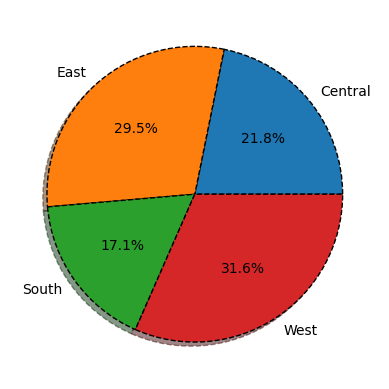

In [47]:
regional_sales=df.groupby("Region")["Sales"].sum()

plt.pie(
    regional_sales,
    labels=regional_sales.index,
    autopct="%1.1f%%",
    shadow=True,
    wedgeprops={"edgecolor":"black","linestyle":"--"}
)